In [1]:
import torch
import sys
from pathlib import Path

from src.model import SiamNet
from src.dataset import ImageTransformer, TransformTokenizer, TRANSFORM_TOKENS
from PIL import Image
from omegaconf import OmegaConf
from torchvision import transforms
import os

%load_ext autoreload
%autoreload 2

In [2]:
# !pip install efficientnet-pytorch

In [2]:
model = SiamNet()

checkpoint_path = "/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/siamnet_pretrain/checkpoint_epoch_12.pth"

checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to('cpu')
model.eval()
print('ready')

Loaded pretrained weights for efficientnet-b3
ready


In [3]:
preprocess = transforms.Compose([
            transforms.Resize((300, 300)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

['rotate_90', 'grayscale']


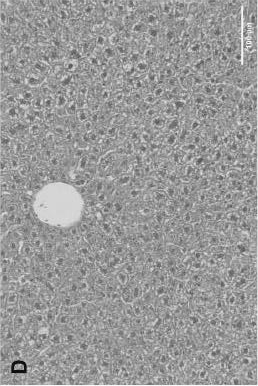

In [4]:
image_path_1 = '/mnt/DATA2/dorin/imgs/bio_from_prod/image_7.jpg'
image_path_2 = '/mnt/DATA2/dorin/imgs/bio_from_prod/image_4.jpg'
# image_path_1 = "/mnt/DATA2/dorin/imgs/bio_from_prod/image_12.jpg"
# image_path_2 = "/mnt/DATA2/dorin/imgs/bio_from_prod/image_10.jpg"

image_1 = Image.open(image_path_1)
image_2 = Image.open(image_path_2)

# image_1.show()
# image_2.show()

it = ImageTransformer()
transformed_image_1, sequence_1 = it.transform(image_1, p=0.3)
print(sequence_1)
transformed_image_1

In [5]:
image_tensor_1 = preprocess(image_1).unsqueeze(0)
image_tensor_2 = preprocess(image_2).unsqueeze(0)
transformed_image_tensor = preprocess(transformed_image_1).unsqueeze(0)

score = model.predict_similarity(image_tensor_1, image_tensor_2)
score

tensor([2.4208e-18], grad_fn=<SqueezeBackward1>)

In [6]:
# torch.save(model.state_dict(), "/mnt/DATA2/dorin/Image-Transform-Predict/checkpoints/siamnet_pretrain/model_weights.pth")